In [1]:
class Linear_Model():
    def predict(self, x, w, b):
        '''
        This is the linear regression model which gives predicition
        formula used:
        F(w,b) for given x : w * x[i] + b
        WHERE ->
        w is weight/slope calculated here using gradient descent,
        b is bias/y-intercept calculated using gradient decscent.
        x is input
        '''
        m = x.shape[0]
        output = pd.Series(dtype=float)
        for i in range(m):
            new_value = pd.Series([w * x[i] + b])
            output = pd.concat([output, new_value], ignore_index=True)
        return output
    def cost_function_engine(self, x_train, y_train, w, b):
        '''
        This is Cost Function calculator
        formula used : 1/2m{∑(wx[i] + b - y[i])^2}
        WHERE ->
        * m = number of training examples
        * x[i] = input
        * y[i] = actual output
        * (w*x[i] + b) = prediction (y_hat)
        '''
        m = x_train.shape[0]
        cost = 0

        for i in range(m):
            model_func = w*x_train[i] + b
            cost += ((model_func) - y_train[i])**2
        return (1/(2*m)) * cost
    def batch_gradient_descent(self, x_train, y_train, w, b, learn_rate, iterations):
        '''
        This is Gradient Descent calculator
        formula used :
        for w : w - alpha * (1/m) * ∑(((w*x[i] + b) - y[i]) * x[i])
        for b : b - alpha * (1/m) * ∑((w*x[i] + b) - y[i])
        WHERE ->
        * alpha = learning rate
        * m = number of training examples
        * x[i] = input
        * y[i] = actual output
        * (w*x[i] + b) = prediction (y_hat)
        '''
        m = x_train.shape[0]
        for j in range(iterations):
            w_error = 0
            b_error = 0
            for i in range(m):
                model_func = w * x_train[i] + b
                target_y = y_train[i]
                error = ((model_func) - target_y)
                w_error += error * x_train[i]
                b_error += error
            dj_dw = (1 / m) * w_error
            dj_db = (1 / m) * b_error
            w = w - learn_rate * dj_dw
            b = b - learn_rate * dj_db
            cost = self.cost_function_engine(x_train, y_train, w, b)
            print(cost)
        return [w, b]

In [2]:
import pandas as pd

# dummy training data
x_train = pd.Series([1, 2, 3, 4, 5])
y_train = pd.Series([5, 7, 9, 11, 13])

# initial values
w = 0
b = 0

# learning rate (alpha)
learn_rate = 0.01

# number of iterations
iterations = 1000

# create object
model = Linear_Model()

# train model
trained_values = model.batch_gradient_descent(
    x_train,
    y_train,
    w,
    b,
    learn_rate,
    iterations
)

# get trained w and b
trained_w = trained_values[0]
trained_b = trained_values[1]

print("\nFinal Weight:", trained_w)
print("Final Bias:", trained_b)

# predictions
predictions = model.predict(x_train, trained_w, trained_b)

print("\nPredictions:")
print(predictions)

34.6963
27.07477042
21.149613519627998
16.543180768393416
12.961896463586548
10.177541278000966
8.01270249974125
6.329463367225525
5.020610405870447
4.002798204150929
3.211235860170391
2.5955563415680043
2.1166054163534738
1.7439454380463173
1.4539148428992614
1.228119645528212
1.0522607606445664
0.9152223886464013
0.8083633465373856
0.7249661640998502
0.6598088233220681
0.6088318380060151
0.5688794487438988
0.5374984335595667
0.5127817077062607
0.49324674157382775
0.4777410454318609
0.4653686953384455
0.455433215990335
0.4473931791012559
0.4408276865533548
0.4354095377548685
0.43088437053144396
0.4270544457117402
0.42376604161927545
0.4208996548263544
0.4183623824346939
0.4160820002271335
0.4140023591523956
0.41207980665309735
0.4102804046844636
0.40857776706294563
0.40695137826835226
0.40538528651739425
0.4038670877876405
0.4023871360199383
0.40093792914703674
0.399513631805639
0.3981097043031607
0.39672261418458005
0.3953496120107742
0.3939885570534769
0.3926377817943127
0.391295986

Iteration 1 : Cost = 34.6963
Iteration 2 : Cost = 27.07477042
Iteration 3 : Cost = 21.149613519627998
Iteration 4 : Cost = 16.543180768393416
Iteration 5 : Cost = 12.961896463586548
Iteration 6 : Cost = 10.177541278000966
Iteration 7 : Cost = 8.01270249974125
Iteration 8 : Cost = 6.329463367225525
Iteration 9 : Cost = 5.020610405870447
Iteration 10 : Cost = 4.002798204150929
Iteration 11 : Cost = 3.211235860170391
Iteration 12 : Cost = 2.5955563415680043
Iteration 13 : Cost = 2.1166054163534738
Iteration 14 : Cost = 1.7439454380463173
Iteration 15 : Cost = 1.4539148428992614
Iteration 16 : Cost = 1.228119645528212
Iteration 17 : Cost = 1.0522607606445664
Iteration 18 : Cost = 0.9152223886464013
Iteration 19 : Cost = 0.8083633465373856
Iteration 20 : Cost = 0.7249661640998502
Iteration 21 : Cost = 0.6598088233220681
Iteration 22 : Cost = 0.6088318380060151
Iteration 23 : Cost = 0.5688794487438988
Iteration 24 : Cost = 0.5374984335595667
Iteration 25 : Cost = 0.5127817077062607
Iteration

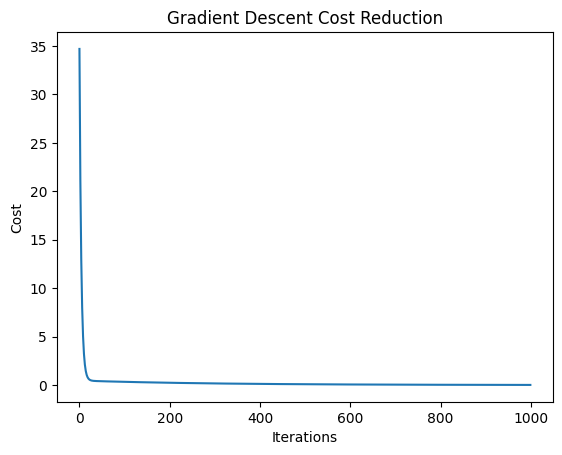

In [3]:
import pandas as pd
import matplotlib.pyplot as plt


class Linear_Model():

    def predict(self, x, w, b):
        '''
        Linear Regression Prediction
        formula:
        y = wx + b
        '''

        output = []

        for i in range(x.shape[0]):
            prediction = w * x[i] + b
            output.append(prediction)

        return pd.Series(output)

    def cost_function_engine(self, x_train, y_train, w, b):
        '''
        Cost Function

        formula:
        J(w,b) = 1/2m * Σ((wx + b) - y)^2
        '''

        m = x_train.shape[0]

        total_cost = 0

        for i in range(m):

            prediction = w * x_train[i] + b

            error = prediction - y_train[i]

            total_cost += error ** 2

        final_cost = (1 / (2 * m)) * total_cost

        return final_cost

    def batch_gradient_descent(
        self,
        x_train,
        y_train,
        w,
        b,
        learn_rate,
        iterations
    ):
        '''
        Gradient Descent
        '''

        m = x_train.shape[0]

        # store all costs for graph
        cost_history = []

        for j in range(iterations):

            w_error = 0
            b_error = 0

            for i in range(m):

                prediction = w * x_train[i] + b

                actual_value = y_train[i]

                error = prediction - actual_value

                w_error += error * x_train[i]

                b_error += error

            # derivatives
            dj_dw = (1 / m) * w_error
            dj_db = (1 / m) * b_error

            # update parameters
            w = w - learn_rate * dj_dw
            b = b - learn_rate * dj_db

            # calculate cost
            cost = self.cost_function_engine(
                x_train,
                y_train,
                w,
                b
            )

            # save cost
            cost_history.append(cost)

            print(f"Iteration {j+1} : Cost = {cost}")

        return [w, b, cost_history]


# -----------------------------
# DUMMY TRAINING DATA
# -----------------------------

x_train = pd.Series([1, 2, 3, 4, 5])

y_train = pd.Series([5, 7, 9, 11, 13])

# equation is:
# y = 2x + 3


# -----------------------------
# INITIAL VALUES
# -----------------------------

w = 0
b = 0

learn_rate = 0.01

iterations = 1000


# -----------------------------
# CREATE MODEL
# -----------------------------

model = Linear_Model()


# -----------------------------
# TRAIN MODEL
# -----------------------------

result = model.batch_gradient_descent(
    x_train,
    y_train,
    w,
    b,
    learn_rate,
    iterations
)

trained_w = result[0]

trained_b = result[1]

cost_history = result[2]


# -----------------------------
# FINAL VALUES
# -----------------------------

print("\nFinal Weight:", trained_w)

print("Final Bias:", trained_b)


# -----------------------------
# PREDICTIONS
# -----------------------------

predictions = model.predict(
    x_train,
    trained_w,
    trained_b
)

print("\nPredictions:")

print(predictions)


# -----------------------------
# COST GRAPH
# -----------------------------

plt.plot(cost_history)

plt.xlabel("Iterations")

plt.ylabel("Cost")

plt.title("Gradient Descent Cost Reduction")

plt.show()